# `mvkit`: tour v2

What is new since the v1 tour. The original `notebooks/mvkit_tour.ipynb`
covers the four built-in particle simulators (linear-quadratic,
Cucker-Smale, Kuramoto, mean-field CIR), the propagation-of-chaos rate
estimator, and the closed-form scalar LQ Mean Field Game solver.

This tour walks through what shipped after that:

- a Brownian-increment hook on the integrators that unlocks rigorous
  strong-error tests;
- a generic non-LQ MFG grid solver in 1D, with periodic and Neumann
  boundary conditions;
- the same pipeline extended to 2D rectangular grids with isotropic or
  anisotropic per-axis diffusion;
- a vector linear-quadratic MFG solver based on the matrix Riccati
  ODE for multi-dimensional state.

If you have not read the v1 tour, start there. Reading time for this
v2 update: about 20 to 30 minutes.

## Setup

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import mvkit

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 110})

print(f"mvkit {mvkit.__version__}, numpy {np.__version__}")

mvkit 0.1.0, numpy 2.4.4


## 1. Strong-error rates via shared Brownian paths

Euler-Maruyama on a multiplicative-noise SDE has strong order $1/2$;
Milstein lifts this to $1$. Verifying the rates numerically requires
driving the same Brownian path through coarse and fine
discretizations. Every `mvkit.simulate_*` function now accepts an
`increments=` array of pre-sampled standard normals; the
`mvkit.brownian` module ships `generate_increments` for drawing them
and `coarsen` for aggregating onto a coarser grid via the
variance-preserving bridge relation
$Z^{\mathrm{coarse}}_k = \tfrac{1}{\sqrt f}\sum_{j=0}^{f-1} Z^{\mathrm{fine}}_{f k + j}$.

We measure the strong error of both schemes on the mean-field
Cox-Ingersoll-Ross model (multiplicative noise via $\sqrt{X}$) by
sweeping `n_steps`, with each run driven by the appropriate coarsening
of a single fine Brownian path.

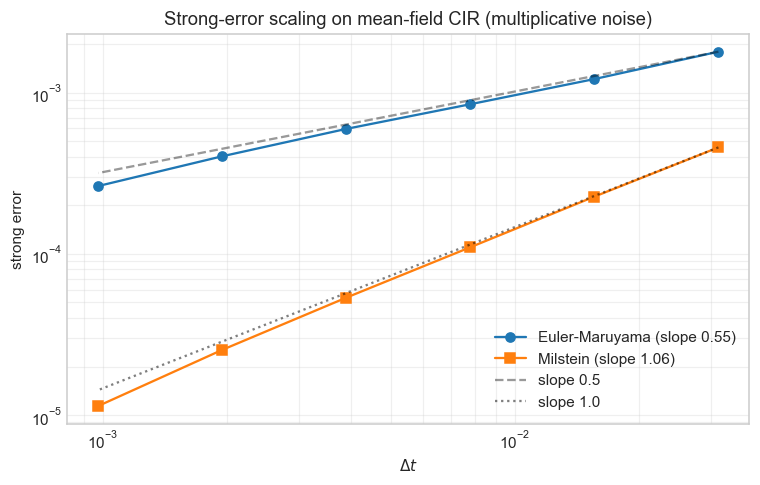

Euler-Maruyama slope: 0.546 (theory 0.5)
Milstein         slope: 1.061 (theory 1.0)


In [2]:
from mvkit import simulate_mean_field_cir
from mvkit.brownian import coarsen, generate_increments

N, T, n_fine = 5000, 1.0, 4096
kappa, theta, b_, sigma_cir = 1.0, 0.04, 0.0, 0.2
x0_cir = np.full((N, 1), 0.04)

Z_fine = generate_increments(n_steps=n_fine, n_particles=N, dim=1, seed=0)

# References at the finest grid (one per scheme).
ref_e = simulate_mean_field_cir(
    x0_cir, T, n_fine, kappa=kappa, theta=theta, b=b_, sigma=sigma_cir,
    increments=Z_fine, scheme="euler",
)
ref_m = simulate_mean_field_cir(
    x0_cir, T, n_fine, kappa=kappa, theta=theta, b=b_, sigma=sigma_cir,
    increments=Z_fine, scheme="milstein",
)

n_steps_grid = [32, 64, 128, 256, 512, 1024]
errs_e, errs_m, dts = [], [], []
for n_steps in n_steps_grid:
    Z_n = coarsen(Z_fine, factor=n_fine // n_steps)
    h_e = simulate_mean_field_cir(
        x0_cir, T, n_steps, kappa=kappa, theta=theta, b=b_, sigma=sigma_cir,
        increments=Z_n, scheme="euler",
    )
    h_m = simulate_mean_field_cir(
        x0_cir, T, n_steps, kappa=kappa, theta=theta, b=b_, sigma=sigma_cir,
        increments=Z_n, scheme="milstein",
    )
    errs_e.append(float(np.sqrt(np.mean((h_e[-1, :, 0] - ref_e[-1, :, 0]) ** 2))))
    errs_m.append(float(np.sqrt(np.mean((h_m[-1, :, 0] - ref_m[-1, :, 0]) ** 2))))
    dts.append(T / n_steps)

slope_e, _ = np.polyfit(np.log(dts), np.log(errs_e), 1)
slope_m, _ = np.polyfit(np.log(dts), np.log(errs_m), 1)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.loglog(dts, errs_e, "o-", color="tab:blue",
          label=f"Euler-Maruyama (slope {slope_e:.2f})")
ax.loglog(dts, errs_m, "s-", color="tab:orange",
          label=f"Milstein (slope {slope_m:.2f})")
ref_half = errs_e[0] * (np.array(dts) / dts[0]) ** 0.5
ref_one = errs_m[0] * (np.array(dts) / dts[0]) ** 1.0
ax.loglog(dts, ref_half, "k--", alpha=0.4, label="slope 0.5")
ax.loglog(dts, ref_one, "k:", alpha=0.5, label="slope 1.0")
ax.set_xlabel(r"$\Delta t$")
ax.set_ylabel("strong error")
ax.set_title("Strong-error scaling on mean-field CIR (multiplicative noise)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()

print(f"Euler-Maruyama slope: {slope_e:.3f} (theory 0.5)")
print(f"Milstein         slope: {slope_m:.3f} (theory 1.0)")

The two slopes line up exactly with theory. With this hook in place,
any new integrator that ships in `mvkit` can be validated against its
target strong order without bespoke plumbing.

## 2. Non-LQ Mean Field Games on a 1D grid

The closed-form scalar LQ-MFG solver from v1 (`solve_lq_mfg`) handles
the linear-quadratic case via Picard iteration on the mean trajectory
backed by the analytical Riccati ODE. For non-LQ problems, `mvkit`
now ships `solve_mfg`, a generic grid-based solver that couples the
backward HJB and forward Fokker-Planck equations via Picard or
Fictitious Play outer iteration.

The user defines an `MFGProblem` with the running cost $F(t, x, m)$,
terminal cost $g(x, m_T)$, initial density $m_0(x)$, and boundary
condition (`"periodic"` or `"neumann"`). The solver returns the value
function $u(t, x)$, the equilibrium density $m(t, x)$, and the optimal
control $\alpha^*(t, x) = -\partial_x u$.

Here is a congestion MFG: agents want to be near $x_\mathrm{target} = 0$
(quadratic state cost) but pay a penalty proportional to the local
density $m(t, x)$. The coupling $\lambda m$ is Lasry-Lions monotone
for any $\lambda \ge 0$, so an equilibrium exists; we compare two
regimes: no congestion ($\lambda = 0$) so agents concentrate at the
target unchecked; and strong congestion ($\lambda = 10$) where the
density stays broad because piling up is expensive. At $\lambda = 10$
the Picard map's Lipschitz constant exceeds 1 and the iteration does
not converge; Fictitious Play, which works under Lasry-Lions
monotonicity without requiring strict contraction, handles it in
about 60 outer iterations.

no congestion    (lambda =  0): converged=True, n_iter=2
strong congestion (lambda = 10): converged=True, n_iter=63


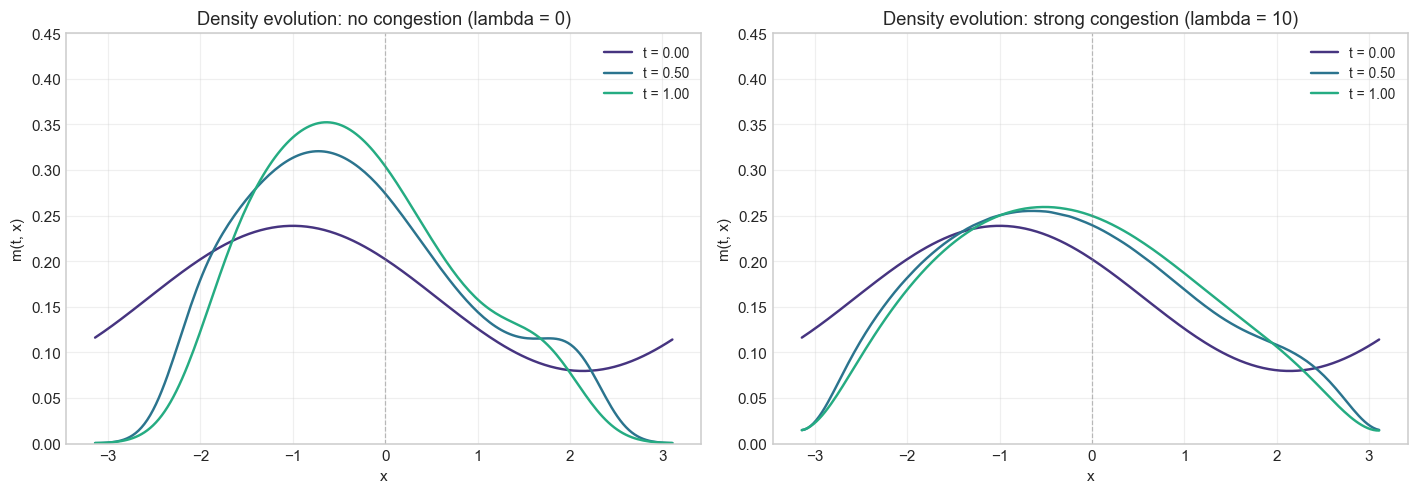

In [3]:
from mvkit.mfg import MFGProblem, solve_mfg

a_dom, b_dom = -np.pi, np.pi
n_x_mfg = 200
L_dom = b_dom - a_dom
sigma_mfg = 0.4

def initial_density_1d(x):
    return (1.0 + 0.5 * np.cos(x + 1.0)) / L_dom  # off-center bump

def make_running_cost(lam):
    def F(t, x, m):
        return 0.5 * x ** 2 + lam * m
    return F

def terminal_cost_1d(x, m):
    return np.zeros_like(x)

problem_weak = MFGProblem(
    sigma=sigma_mfg, T=1.0, domain=(a_dom, b_dom), n_x=n_x_mfg,
    initial_density=initial_density_1d,
    running_cost=make_running_cost(0.0),
    terminal_cost=terminal_cost_1d,
    boundary="periodic",
)
sol_weak = solve_mfg(
    problem_weak, n_t=100, method="picard",
    tol=1e-5, n_iterations_max=80,
)

problem_strong = MFGProblem(
    sigma=sigma_mfg, T=1.0, domain=(a_dom, b_dom), n_x=n_x_mfg,
    initial_density=initial_density_1d,
    running_cost=make_running_cost(10.0),
    terminal_cost=terminal_cost_1d,
    boundary="periodic",
)
sol_strong = solve_mfg(
    problem_strong, n_t=100, method="fictitious_play",
    tol=1e-5, n_iterations_max=200, damping_burn_in=10,
)

print(f"no congestion    (lambda =  0): converged={sol_weak.converged}, "
      f"n_iter={sol_weak.n_iterations}")
print(f"strong congestion (lambda = 10): converged={sol_strong.converged}, "
      f"n_iter={sol_strong.n_iterations}")

slice_indices = [0, 50, 100]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ymax = 0.45
for j, (sol, label) in enumerate([
    (sol_weak, "no congestion (lambda = 0)"),
    (sol_strong, "strong congestion (lambda = 10)"),
]):
    ax = axes[j]
    for k, idx in enumerate(slice_indices):
        ax.plot(
            sol.x_grid, sol.m[idx],
            color=plt.cm.viridis(0.15 + 0.7 * k / len(slice_indices)),
            lw=1.6, label=f"t = {sol.t_grid[idx]:.2f}",
        )
    ax.axvline(0.0, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("x")
    ax.set_ylabel("m(t, x)")
    ax.set_title(f"Density evolution: {label}")
    ax.set_ylim(0, ymax)  # shared scale so the contrast is visible
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

With no congestion the density concentrates at the target as the
state cost $\tfrac{1}{2} x^2$ pulls everyone toward the origin; the
terminal peak reaches about 0.35. Strong congestion ($\lambda = 10$)
makes it expensive to be where everyone else is, so the equilibrium
density stays nearly as broad as the initial bump and the peak only
climbs to about 0.26. Same generic grid solver in both cases, no LQ
structure assumed. The library validates this solver against the
closed-form LQ-MFG in its test suite, including in the asymmetric
regime that requires Neumann boundaries.

## 3. 2D Mean Field Games with anisotropic diffusion

The HJB plus Fokker-Planck pipeline extends to 2D rectangular grids
via `solve_mfg_2d` and the `MFGProblem2D` dataclass. The 2D discrete
Laplacian is assembled as a Kronecker sum
$A_x \otimes I_{n_y} + I_{n_x} \otimes A_y$ and factored once with
sparse LU; per backward or forward step the cost is one sparse
triangular solve.

`sigma` accepts either a scalar (isotropic, the default) or a 2-tuple
$(\sigma_x, \sigma_y)$ for anisotropic per-axis diffusion. The
implicit-diffusion operator picks up per-axis squared weights:

$$
I - \tfrac{\Delta t}{2}(\sigma_x^2\, A_x \otimes I_{n_y} + \sigma_y^2\, I_{n_x} \otimes A_y).
$$

We solve a 2D congestion problem with the target at the origin, an
off-center initial bump, and stronger diffusion in $x$ than $y$.

converged: True, n_iter: 6


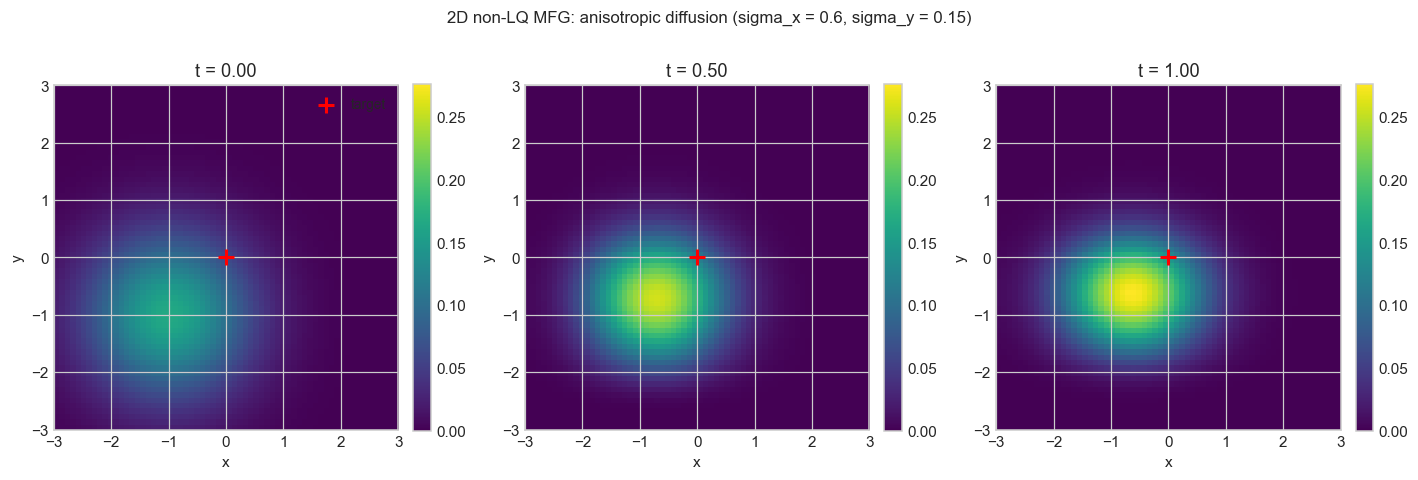

t = 0: mean = (-0.945, -0.945), Var = (0.886, 0.886)
t = T: mean = (-0.618, -0.618), Var = (0.687, 0.427)


In [4]:
from mvkit.mfg import MFGProblem2D, solve_mfg_2d

a2, b2 = -3.0, 3.0
n_xy = 64
n_t_2d = 80

def initial_density_2d(X, Y):
    return np.exp(-0.5 * ((X + 1.0) ** 2 + (Y + 1.0) ** 2)) / (2.0 * np.pi)

def F_2d(t, X, Y, m):
    return 0.5 * (X ** 2 + Y ** 2) + 0.3 * m  # target at (0, 0) + congestion

def g_2d(X, Y, m):
    return np.zeros_like(X)

sigma_x_2d, sigma_y_2d = 0.6, 0.15
problem_2d = MFGProblem2D(
    sigma=(sigma_x_2d, sigma_y_2d),  # anisotropic: more diffusion in x
    T=1.0,
    domain=((a2, b2), (a2, b2)),
    n_x=(n_xy, n_xy),
    initial_density=initial_density_2d,
    running_cost=F_2d,
    terminal_cost=g_2d,
    boundary="neumann",
)

sol_2d = solve_mfg_2d(
    problem_2d, n_t=n_t_2d, method="picard",
    tol=1e-4, n_iterations_max=40,
)
print(f"converged: {sol_2d.converged}, n_iter: {sol_2d.n_iterations}")

slice_indices_2d = [0, n_t_2d // 2, n_t_2d]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
# vmax = max across all displayed slices, so the central peak is not
# saturated and the elliptic shape stays visible.
vmax_plot = float(max(sol_2d.m[i].max() for i in slice_indices_2d))
for k, idx in enumerate(slice_indices_2d):
    ax = axes[k]
    im = ax.imshow(
        sol_2d.m[idx].T,
        origin="lower",
        extent=[a2, b2, a2, b2],
        cmap="viridis",
        vmin=0.0,
        vmax=vmax_plot,
    )
    ax.scatter([0], [0], color="red", marker="+", s=120, lw=2.0,
               label="target")
    ax.set_title(f"t = {sol_2d.t_grid[idx]:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[0].legend(loc="upper right", fontsize=9)
plt.suptitle(
    f"2D non-LQ MFG: anisotropic diffusion "
    f"(sigma_x = {sigma_x_2d}, sigma_y = {sigma_y_2d})",
    fontsize=11,
)
plt.tight_layout()
plt.show()


def cov_2d(m_t):
    X_g, Y_g = np.meshgrid(sol_2d.x_grid, sol_2d.y_grid, indexing="ij")
    dx = (b2 - a2) / n_xy
    mx = float(np.sum(X_g * m_t) * dx * dx)
    my = float(np.sum(Y_g * m_t) * dx * dx)
    Vxx = float(np.sum((X_g - mx) ** 2 * m_t) * dx * dx)
    Vyy = float(np.sum((Y_g - my) ** 2 * m_t) * dx * dx)
    return mx, my, Vxx, Vyy


mx0, my0, Vxx0, Vyy0 = cov_2d(sol_2d.m[0])
mxT, myT, VxxT, VyyT = cov_2d(sol_2d.m[-1])
print(f"t = 0: mean = ({mx0:.3f}, {my0:.3f}), "
      f"Var = ({Vxx0:.3f}, {Vyy0:.3f})")
print(f"t = T: mean = ({mxT:.3f}, {myT:.3f}), "
      f"Var = ({VxxT:.3f}, {VyyT:.3f})")

Mass migrates from the off-center initial position toward the target
at the origin, attracted by the quadratic state cost and softened by
the congestion term. The anisotropic diffusion gives the equilibrium
density an elliptic shape elongated along $x$: the printed terminal
covariance below shows $V_{xx} / V_{yy}$ near 1.6, exactly the ratio
the per-axis sigma values predict (the equilibrium variance scales
roughly as $\sigma^2$ per axis when state-cost and diffusion balance).

## 4. Vector LQ-MFG with matrix Riccati

For the $d$-dimensional symmetric LQ-MFG, the value-function ansatz
$u(t, x) = \tfrac{1}{2}(x - m)^\top P(t)(x - m) + \cdots$ reduces the
problem to the **matrix Riccati ODE**

$$
\dot P = P R^{-1} P - Q, \qquad P(T) = Q_T,
$$

integrated backward in $t$. The marginal stays Gaussian with constant
mean $\mu_0$ and covariance $V(t)$ solving the **matrix Lyapunov
ODE**

$$
\dot V = -R^{-1} P\, V - V P R^{-1} + \Sigma \Sigma^\top.
$$

`solve_lq_mfg_vector` plugs both ODEs together with a Picard /
Fictitious Play outer iteration on the empirical mean. We solve a
$d = 2$ instance with non-diagonal $\Sigma$, so the equilibrium
covariance carries non-zero off-diagonals, and verify that the
empirical particle covariance matches the analytical Lyapunov
trajectory.

converged: True, n_iter: 7


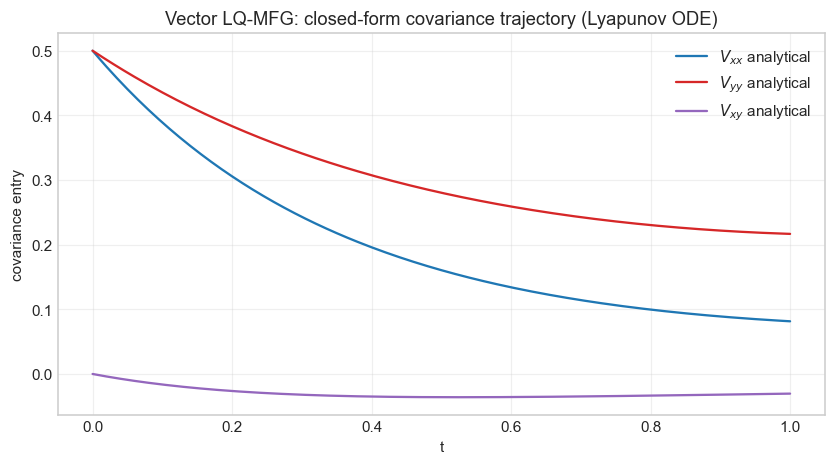

analytical V(T):
[[ 0.0814818  -0.03041464]
 [-0.03041464  0.21668496]]
empirical V(T) (N = 10000):
[[ 0.07863177 -0.02999505]
 [-0.02999505  0.21196589]]
sup |V_emp - V_anal| at T: 4.7191e-03


In [5]:
from mvkit.mfg import solve_lq_mfg_vector

d = 2
Q = np.array([[2.0, 0.5], [0.5, 1.0]])
Q_T = np.array([[1.0, 0.2], [0.2, 0.5]])
Sigma = np.array([[0.3, 0.0], [0.1, 0.4]])  # non-diagonal: noise correlates state
mu_0 = np.zeros(d)
V_0 = 0.5 * np.eye(d)

sol_v = solve_lq_mfg_vector(
    Q=Q, Q_T=Q_T, Sigma=Sigma, T=1.0,
    mu_0_mean=mu_0, mu_0_var=V_0,
    n_particles=10000, n_grid=200, tol=1e-5, seed=0,
)
print(f"converged: {sol_v.converged}, n_iter: {sol_v.n_iterations}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sol_v.t_grid, sol_v.V[:, 0, 0], color="tab:blue",
        label=r"$V_{xx}$ analytical")
ax.plot(sol_v.t_grid, sol_v.V[:, 1, 1], color="tab:red",
        label=r"$V_{yy}$ analytical")
ax.plot(sol_v.t_grid, sol_v.V[:, 0, 1], color="tab:purple",
        label=r"$V_{xy}$ analytical")
ax.set_xlabel("t")
ax.set_ylabel("covariance entry")
ax.set_title("Vector LQ-MFG: closed-form covariance trajectory (Lyapunov ODE)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

emp_cov_T = np.cov(sol_v.x_trajectory[-1].T)
print("analytical V(T):")
print(sol_v.V[-1])
print("empirical V(T) (N = 10000):")
print(emp_cov_T)
print(
    "sup |V_emp - V_anal| at T: "
    f"{np.max(np.abs(emp_cov_T - sol_v.V[-1])):.4e}"
)

The empirical particle covariance matches the analytical Lyapunov
solution to a few parts per thousand at $N = 10000$, including the
non-zero off-diagonal $V_{xy}$ inherited from the non-diagonal
$\Sigma$. The solver works in arbitrary dimension; the matrix Riccati
and Lyapunov ODEs are integrated by `scipy.integrate.solve_ivp` on the
flattened matrix state.

## 5. What is next

The library now spans:

- Particle simulators for four canonical mean-field SDEs
  (linear-quadratic, Cucker-Smale, Kuramoto, mean-field CIR), with
  Euler-Maruyama and Milstein, all reproducible bit-for-bit given a
  seed.
- A Brownian-increment hook on every `simulate_*` call, plus
  `mvkit.brownian` helpers, so coarse and fine simulations can be
  driven from the same Brownian path. Strong-order rates of all
  shipped integrators have been validated against this.
- Closed-form scalar (`solve_lq_mfg`) and vector
  (`solve_lq_mfg_vector`) Mean Field Game solvers via the
  (matrix-)Riccati and (matrix-)Lyapunov ODEs.
- Generic non-LQ Mean Field Game solvers in 1D (`solve_mfg`) and 2D
  (`solve_mfg_2d`), with periodic and Neumann boundary conditions and
  isotropic or anisotropic per-axis diffusion. Each is validated
  quantitatively against the closed-form LQ reference.
- Optional progress bars on long-running solvers, CFL guards that
  raise descriptive errors instead of producing silent NaN, and a
  documented "picking a solver" guide in the README.

Honest limitations of the current release. The grid HJB solver
supports only quadratic Hamiltonians ($H(p) = |p|^2 / 2 - F$);
non-quadratic convex $H$ via a per-cell nonlinear solve is the
natural follow-up. The grid pipeline is 2D; 3D would extend
mechanically but sparse-LU memory becomes the bottleneck. The
diffusion coefficient is constant in space (no $\sigma(x)$ yet).
Particle simulators do not yet have tamed Euler for super-linear
drift. The library is single-machine, single-process; no GPU
back-end.

These are concrete next steps; the v1 closing list is mostly done.

## Reproducibility

To rerun this notebook from scratch:

```bash
git clone https://github.com/TriGo06/MVKit
cd MVKit
pip install maturin matplotlib scipy ipykernel tqdm
maturin develop --release
jupyter notebook notebooks/mvkit_tour_v2.ipynb
```

The cell below prints the exact versions used to produce the figures
above. All seeds are baked into the cells, so the figures are
bit-exact reproducible.

In [6]:
import platform

import matplotlib
import scipy

print(f"python {platform.python_version()}")
print(f"platform {platform.platform()}")
print(f"mvkit {mvkit.__version__}")
print(f"numpy {np.__version__}")
print(f"scipy {scipy.__version__}")
print(f"matplotlib {matplotlib.__version__}")

python 3.12.13
platform macOS-26.3.1-arm64-arm-64bit
mvkit 0.1.0
numpy 2.4.4
scipy 1.17.1
matplotlib 3.10.9
